# CNN - CONVOLUTIONAL NEURAL NETWORK
## OBJECTIVE: 
**Develop a Convolutional Neural Network (CNN) model that can classify fruit images as Fresh or Rotten.**

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

In [2]:
# Load Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(128, 128),
    batch_size=32
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

Found 10901 files belonging to 6 classes.
Found 2702 files belonging to 6 classes.


In [3]:
# Check classes and images
class_names = train_dataset.class_names

print("Fruit Classes:")
print(class_names)

print("Number of Classes:", len(class_names))

Fruit Classes:
['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Number of Classes: 6


In [4]:
# Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [5]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [6]:
# Build CNN
model = Sequential([
    data_augmentation,

    Conv2D(32, (3, 3), activation="relu",
           input_shape=(128, 128, 3)),

    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),

    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),

    Dense(6, activation="softmax")
])

C:\Python314\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
# Display Model Architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 128, 128, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 126, 126, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 63, 63, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 61, 61, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 28, 28, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 14, 14, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 25088)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 128)                   │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 6)                     │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,916,244 (37.83 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,610,830 (25.22 MB)

In [7]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [18]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)


Epoch 1/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 117s 340ms/step - accuracy: 0.9745 - loss: 0.0717 - val_accuracy: 0.9730 - val_loss: 0.0842
Epoch 2/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 119s 346ms/step - accuracy: 0.9807 - loss: 0.0536 - val_accuracy: 0.9874 - val_loss: 0.0314
Epoch 3/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 118s 346ms/step - accuracy: 0.9792 - loss: 0.0603 - val_accuracy: 0.9719 - val_loss: 0.0793
Epoch 4/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 118s 345ms/step - accuracy: 0.9752 - loss: 0.0735 - val_accuracy: 0.9767 - val_loss: 0.0735
Epoch 5/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 118s 346ms/step - accuracy: 0.9796 - loss: 0.0587 - val_accuracy: 0.9697 - val_loss: 0.0985
Epoch 6/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 116s 338ms/step - accuracy: 0.9828 - loss: 0.0518 - val_accuracy: 0.9804 - val_loss: 0.0592
Epoch 7/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 120s 352ms/step - accuracy: 0.9855 - loss: 0.0387 - val_accuracy: 0.9874 - val_loss: 0.0319
Epoch 8/10
341/341 ━━━━━━━━━━━━━━━━━━━━ 119s 348ms/step - accuracy: 0.9890 -

In [30]:
# Evaluate
loss, accuracy = model.evaluate(test_dataset)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


85/85 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.9930 - loss: 0.0245
Test Loss: 0.02450629323720932
Test Accuracy: 0.9929681420326233


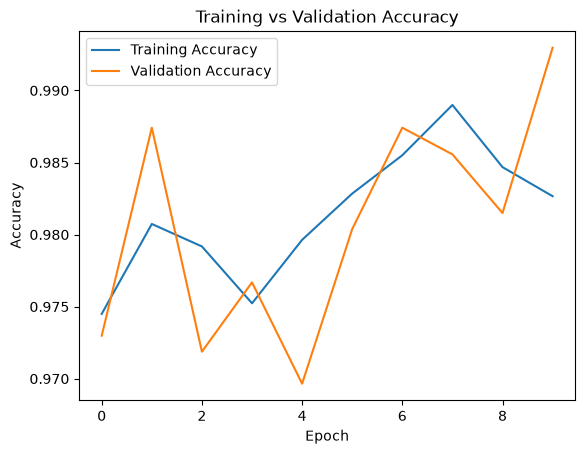

In [31]:
# Training Accuracy Vs Validation Accuracy
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()

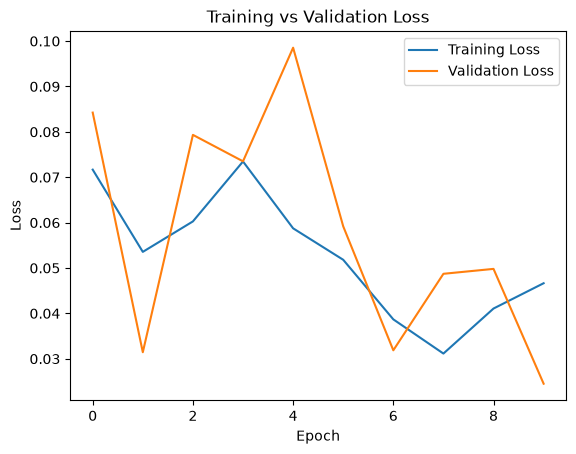

In [32]:
# Training Loss Vs Validation Loss
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

In [22]:
# Predict an Unseen Image
img = tf.keras.utils.load_img(
    "test_image.png",
    target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", confidence, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: freshoranges
Confidence: 99.99998 %


In [23]:
# Check your test folders
import os

test_path = "dataset/test"

for folder in os.listdir(test_path):
    print(folder)

freshapples
freshbanana
freshoranges
rottenapples
rottenbanana
rottenoranges


In [24]:
# Get an actual test image
import os

image_path = None

for root, dirs, files in os.walk("dataset/test"):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_path = os.path.join(root, file)
            break
    if image_path:
        break

print("Image:", image_path)

Image: dataset/test\freshapples\rotated_by_15_Screen Shot 2018-06-08 at 4.59.49 PM.png


In [25]:
# Predict that image
img = tf.keras.utils.load_img(
    image_path,
    target_size=(128, 128)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: freshapples
Confidence: 100.0 %


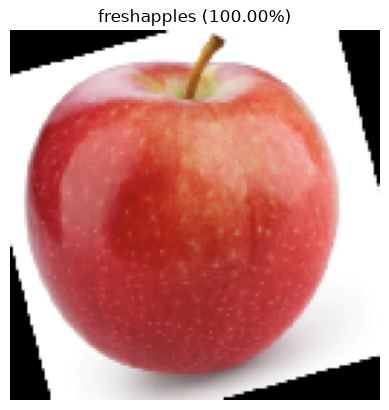

In [26]:
# Display that image too
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()